Integrantes: Alejandra HIdalgo y Antonia Luengo

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
ruta = "/content/drive/MyDrive/IA/number-of-land-animals-slaughtered-for-meat-per-year.csv"
df = pd.read_csv(ruta)

In [7]:
df

,Entity,Code,Year,"Meat, total | 00001765 || Producing or slaughtered animals | 005320 || animals"
0,Afghanistan,AFG,1961,12656000
1,Afghanistan,AFG,1962,13136393
2,Afghanistan,AFG,1963,13606952
3,Afghanistan,AFG,1964,14188000
4,Afghanistan,AFG,1965,14986000
...,...,...,...,...
14232,Zimbabwe,ZWE,2018,56169652
14233,Zimbabwe,ZWE,2019,76447394
14234,Zimbabwe,ZWE,2020,75876846
14235,Zimbabwe,ZWE,2021,76743121


# Preprocesamiento

Renombrar columna para simplificar

In [8]:
df.rename(columns={
    'Meat, total | 00001765 || Producing or slaughtered animals | 005320 || animals': 'Animals_Slaughtered'
}, inplace=True)

Quitar columna de code ya que da la misma información que entity y no necesitamos ambas, nos quedamos con entity ya que hay algunos paises que no cuentan con un codigo, y si nos deshacemos de esas filas no estariamos contando algunos paises

In [9]:
df = df.drop(columns=['Code'])
df

,Entity,Year,Animals_Slaughtered
0,Afghanistan,1961,12656000
1,Afghanistan,1962,13136393
2,Afghanistan,1963,13606952
3,Afghanistan,1964,14188000
4,Afghanistan,1965,14986000
...,...,...,...
14232,Zimbabwe,2018,56169652
14233,Zimbabwe,2019,76447394
14234,Zimbabwe,2020,75876846
14235,Zimbabwe,2021,76743121


Comprobar que no queden valores nulos

In [10]:
df[df.isnull().any(axis=1)]

,Entity,Year,Animals_Slaughtered


# EDA

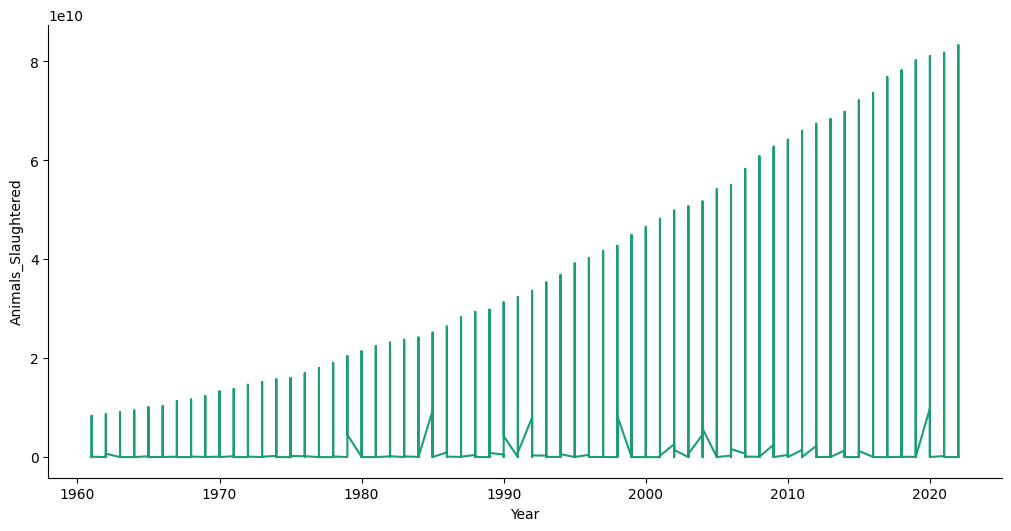

In [ ]:
# @title Year vs Animals_Slaughtered

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Year']
  ys = series['Animals_Slaughtered']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('Year', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Year')
_ = plt.ylabel('Animals_Slaughtered')

El gráfico muestra la cantidad de animales sacrificados a nivel global desde 1960 hasta alrededor de 2022. La línea verde representa un crecimiento constante en el número de animales sacrificados a lo largo del tiempo, con una tendencia claramente ascendente. Se observa que a partir de los años 2000, el número de sacrificios aumenta de forma significativa, alcanzando su punto más alto en los años recientes. En general, el gráfico refleja una tendencia creciente en la demanda o producción de carne a lo largo de las últimas décadas.

## Univariante

In [ ]:
df['Year'].describe()

,Year
count,14237.000000
mean,1992.198567
std,17.863772
min,1961.000000
25%,1977.000000
50%,1993.000000
75%,2008.000000
max,2022.000000


Los datos van desde 1961 a 2022, con un promedio en 1992 y una concentración alrededor de 1993, mostrando una amplia dispersión en décadas.

In [ ]:
df['Animals_Slaughtered'].describe()

,Animals_Slaughtered
count,1.423700e+04
mean,1.104413e+09
std,4.312310e+09
min,0.000000e+00
25%,5.707000e+06
50%,4.076240e+07
75%,3.467660e+08
max,8.329707e+10


Se observa un rango amplio de animales sacrificados, con una media de 1.1 mil millones, una mediana de 40.7 millones, y un máximo de 83.3 mil millones, indicando gran variabilidad en los valores

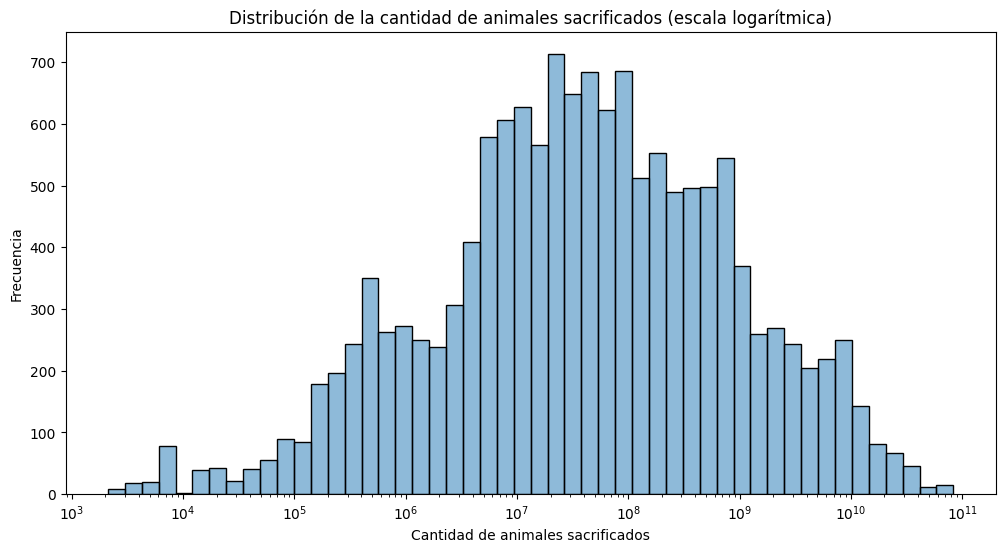

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Animals_Slaughtered'], bins=50, kde=True, log_scale=True)
plt.title('Distribución de la cantidad de animales sacrificados (escala logarítmica)')
plt.xlabel('Cantidad de animales sacrificados')
plt.ylabel('Frecuencia')
plt.show()


El gráfico muestra cómo se distribuye la cantidad de animales sacrificados en una escala logarítmica, destacando que la mayoría de los valores se concentran en el rango de millones a cientos de millones de animales.

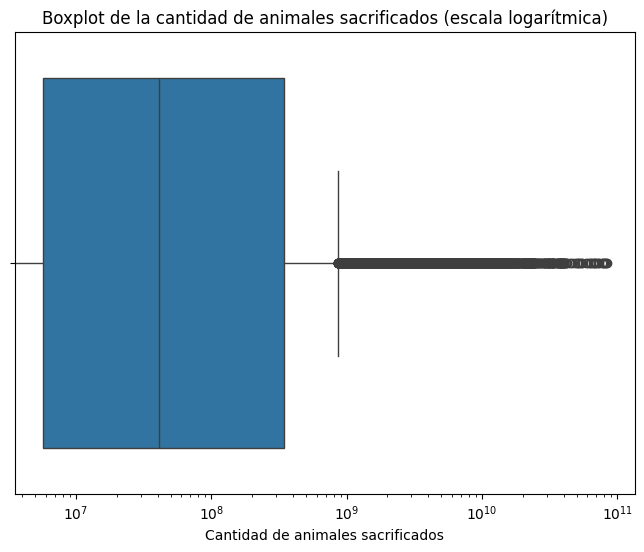

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Animals_Slaughtered'])
plt.title('Boxplot de la cantidad de animales sacrificados (escala logarítmica)')
plt.xlabel('Cantidad de animales sacrificados')
plt.xscale('log')  # Usar escala logarítmica en el eje x
plt.show()

El gráfico de caja muestra que la mayoría de los datos de animales sacrificados se concentran en valores bajos, mientras que hay valores extremos (outliers) que se extienden hacia cantidades mucho más altas.

## Multivariante

In [ ]:
matriz = df[['Year', 'Animals_Slaughtered']].corr()
matriz

,Year,Animals_Slaughtered
Year,1.000000,0.142206
Animals_Slaughtered,0.142206,1.000000


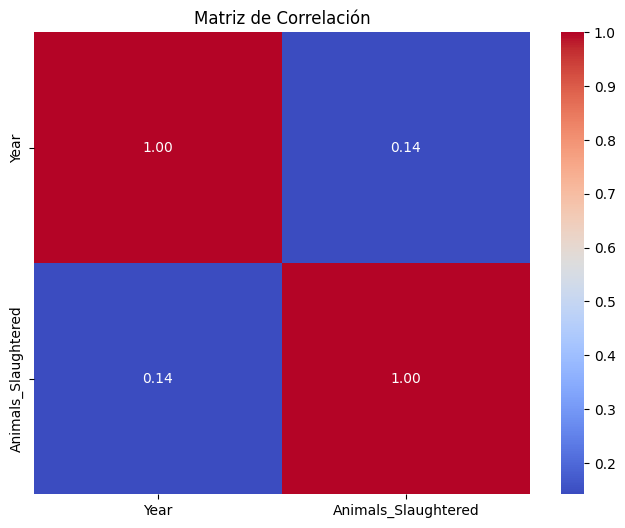

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

La tabla muestra una correlación débil (0.142206) entre el año y el número de animales sacrificados, indicando que a medida que avanzan los años, el número de sacrificios puede aumentar ligeramente.

# Escalar datos

In [5]:
from sklearn.preprocessing import MinMaxScaler

In [11]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Animals_Slaughtered']])
scaled_df = pd.DataFrame(scaled_data, columns=['Scaled_Animals_Slaughtered'])

# Implementación de Algoritmos de Clustering

## K-Means

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

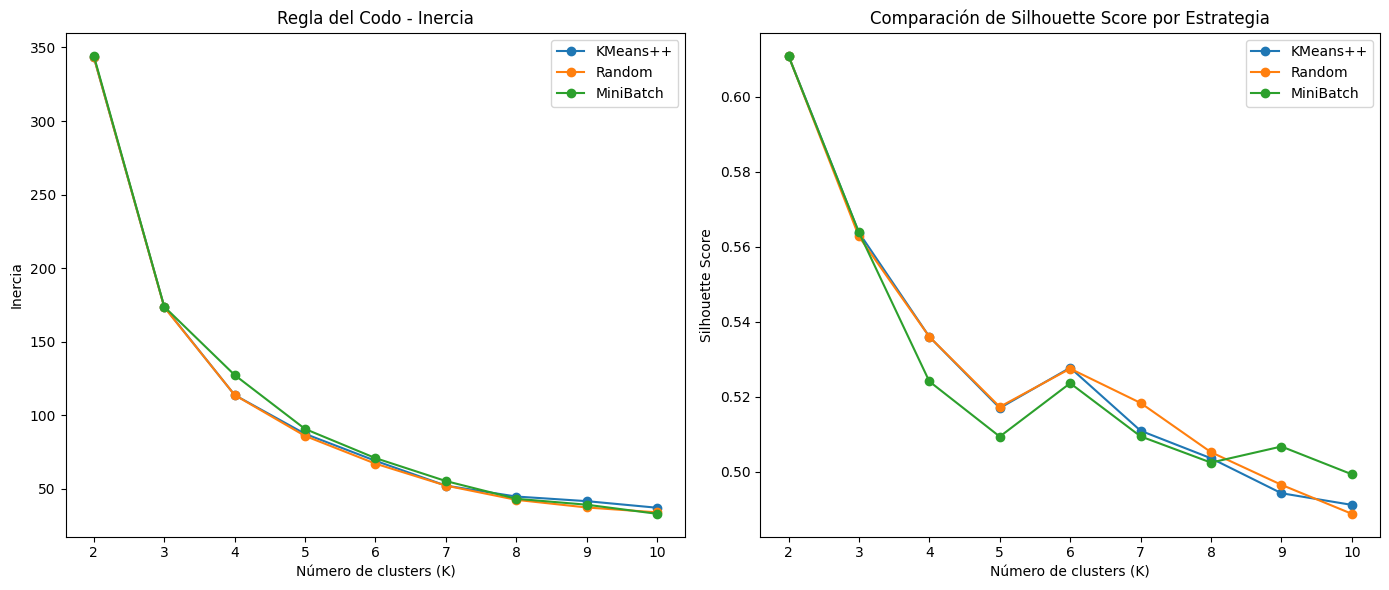

In [18]:
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score

inertia = {}
silhouette_scores = {}

initializations = {
    'KMeans++': 'k-means++',
    'Random': 'random',
    'MiniBatch': 'minibatch'
}

num_clusters = range(2, 11)

for init_name, init in initializations.items():
    inertia[init_name] = []
    silhouette_scores[init_name] = []

    for k in num_clusters:
        if init == 'minibatch':
            model = MiniBatchKMeans(n_clusters=k, init='k-means++', random_state=0)
        else:
            model = KMeans(n_clusters=k, init=init, random_state=0)

        model.fit(df[['Year', 'Animals_Slaughtered']])

        inertia[init_name].append(model.inertia_)
        silhouette_avg = silhouette_score(df[['Year', 'Animals_Slaughtered']], model.labels_)
        silhouette_scores[init_name].append(silhouette_avg)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
for init_name in initializations.keys():
    plt.plot(num_clusters, inertia[init_name], marker='o', label=f'{init_name}')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.title('Regla del Codo - Inercia')
plt.legend()

plt.subplot(1, 2, 2)
for init_name in initializations.keys():
    plt.plot(num_clusters, silhouette_scores[init_name], marker='o', label=f'{init_name}')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Comparación de Silhouette Score por Estrategia')
plt.legend()

plt.tight_layout()
plt.show()


se prueban tres métodos de inicialización para crear los clusters: KMeans++, Random y MiniBatch, comparando cuál funciona mejor. Utilizamos la "Regla del Codo" y el Silhouette Score para medir la calidad de los clusters en distintos valores de K (el número de clusters). La inercia mide cuán compactos están los clusters (valores menores son mejores). Regla del codo grafica la inercia en función del número de clusters ( K ) para encontrar el punto óptimo en que añadir más clusters no mejora significativamente la inercia. Y silhouette Score mide qué tan similares son los puntos de cada cluster entre sí en comparación con los clusters vecinos (valores cercanos a 1 son ideales).

En el primer gráfico, se muestra la Regla del Codo. Al aumentar el número de clusters (K), la "inercia" (suma de distancias entre los puntos y el centro de su cluster) baja rápidamente al principio, pero luego la reducción se vuelve más lenta, formando un "codo" alrededor de (K=4) o (K=5). Este punto marca el número adecuado de clusters, ya que agregar más clusters después de ese punto no mejora mucho la separación entre ellos.

En el segundo gráfico, se utiliza el Silhouette Score. Aquí, el puntaje disminuye al aumentar (K), especialmente después de (K=4), lo que indica que agregar más clusters empeora la claridad de los grupos. De los tres métodos de inicialización (KMeans++, Random y MiniBatch), KMeans++ y Random tienen resultados similares, mientras que MiniBatch tiene un rendimiento un poco menor en valores altos de (K), mostrando clusters de menor calidad.


## DBSCAN

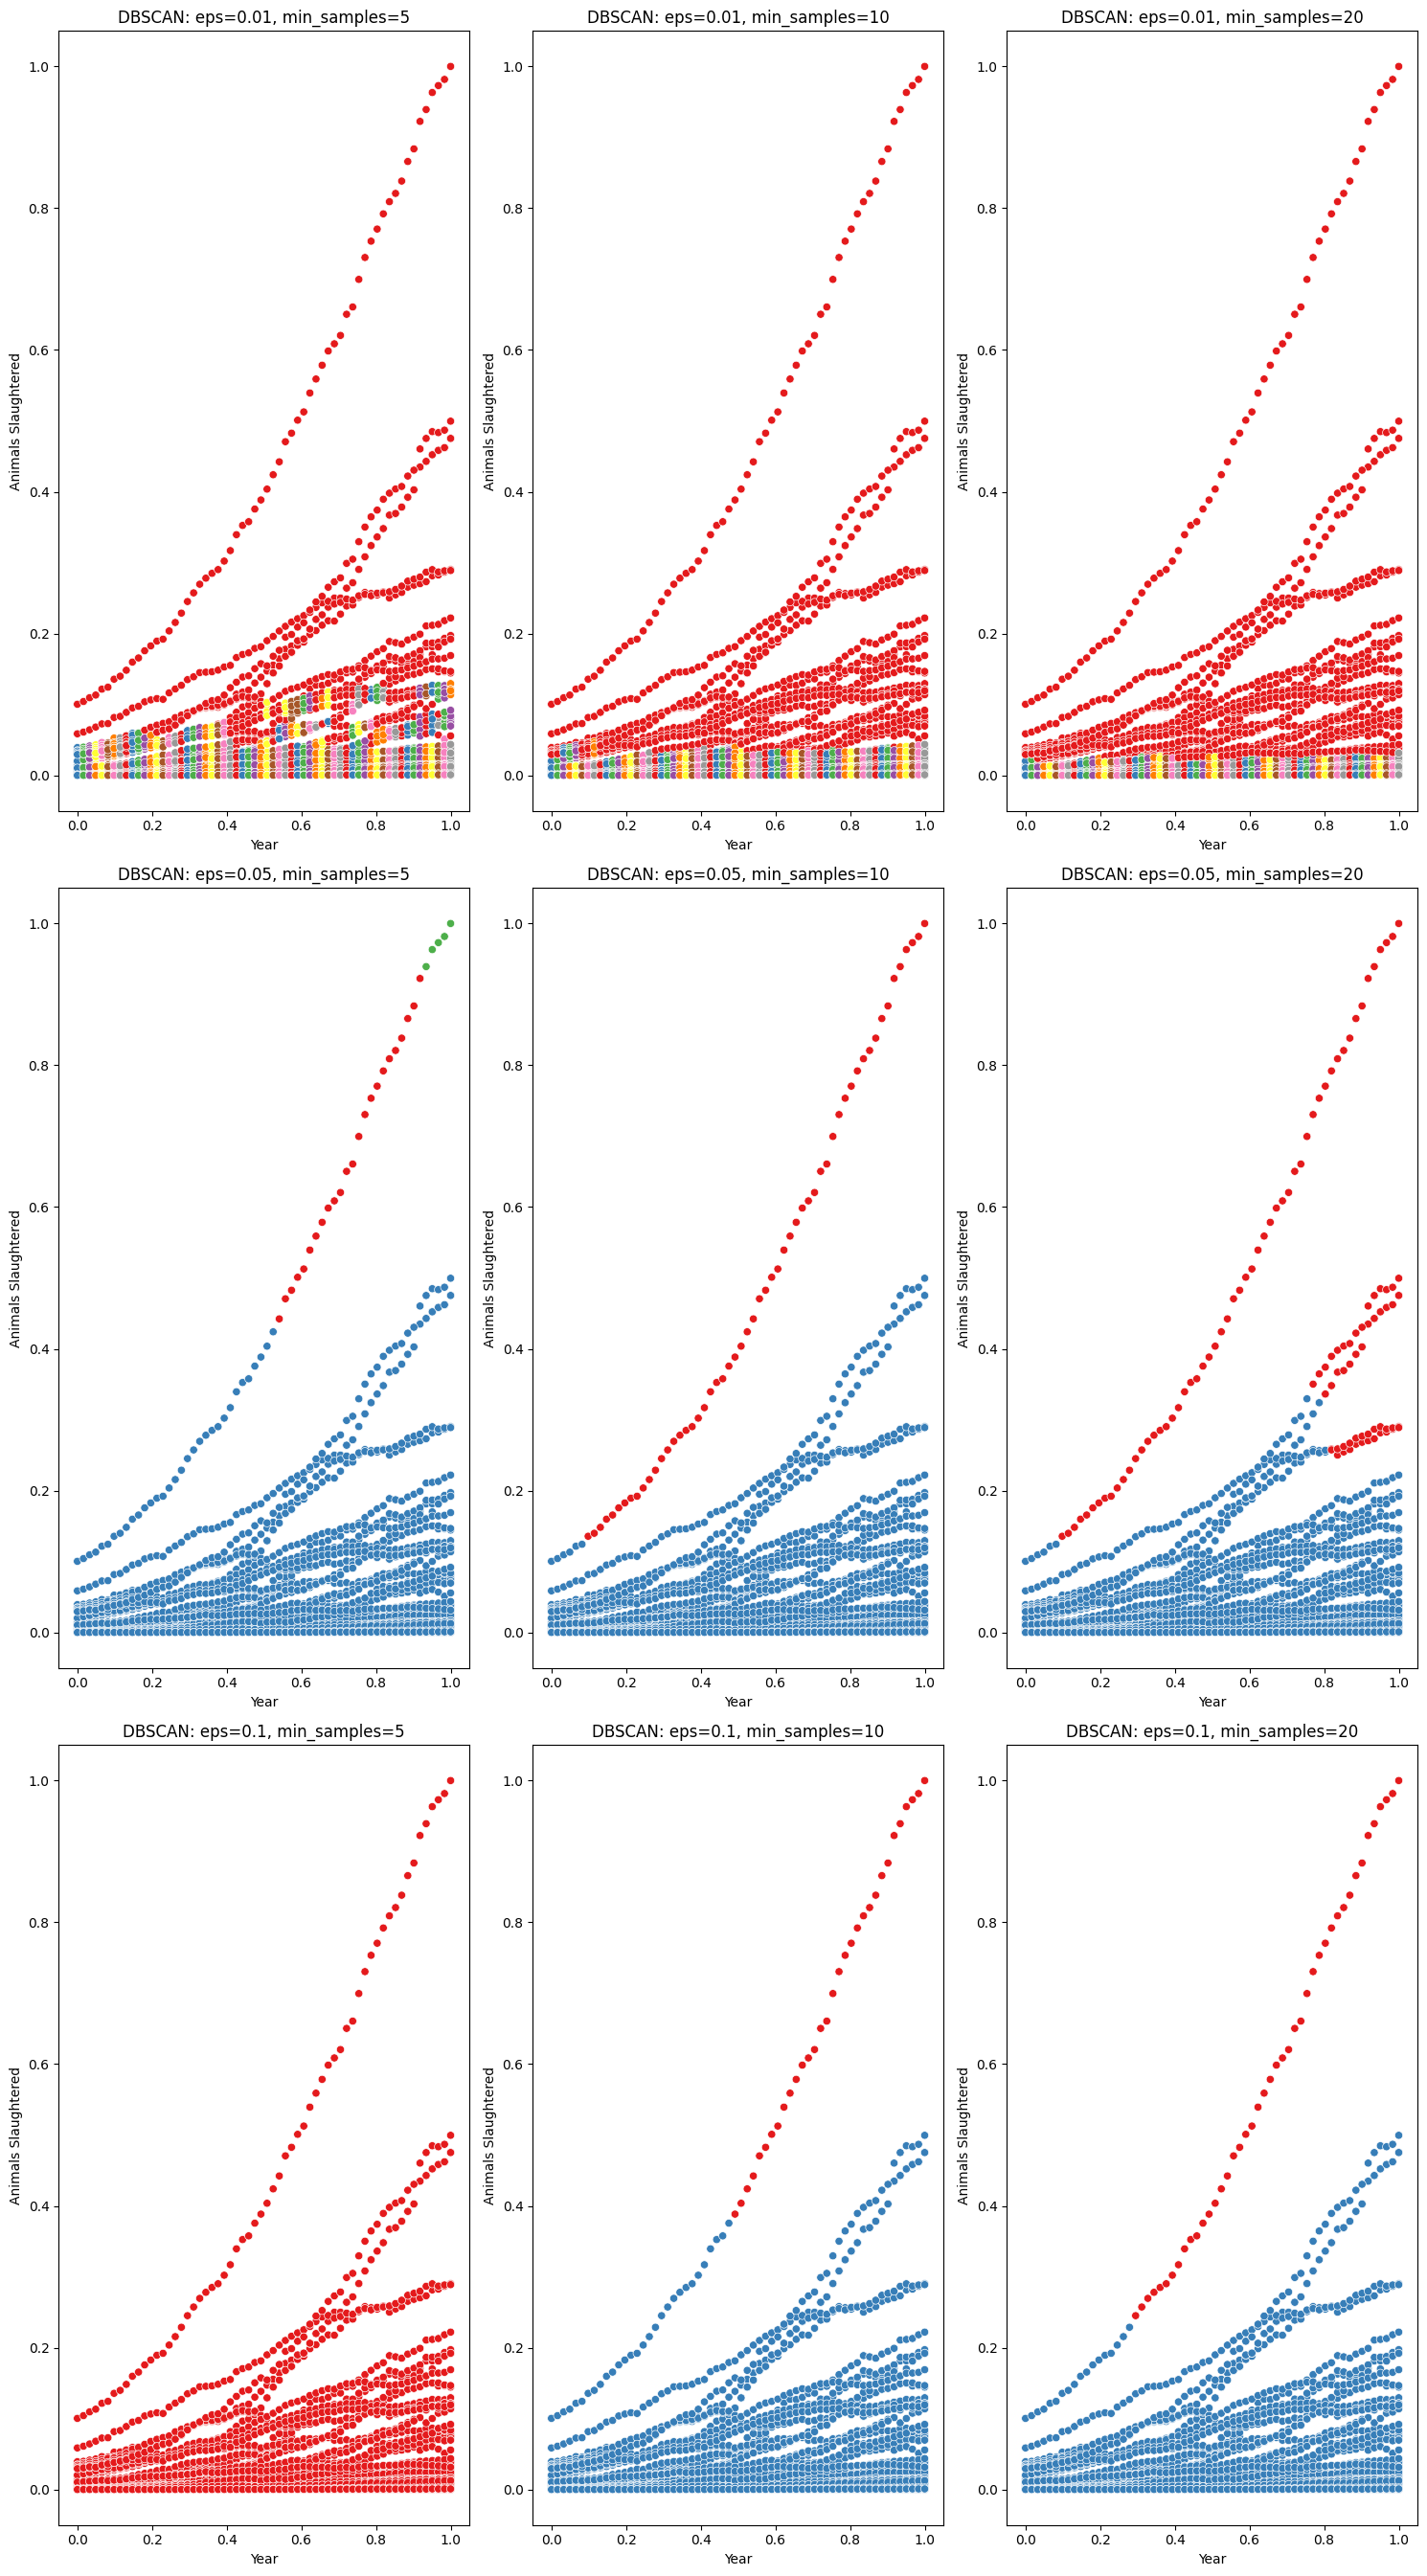

In [17]:
from sklearn.cluster import DBSCAN

eps_values = [0.01, 0.05, 0.1]
min_samples_values = [5, 10, 20]

plt.figure(figsize=(15, len(eps_values) * len(min_samples_values) * 3))

plot_num = 1
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(df[['Year', 'Animals_Slaughtered']])

        plt.subplot(len(eps_values), len(min_samples_values), plot_num)
        sns.scatterplot(x=df['Year'], y=df['Animals_Slaughtered'], hue=labels, palette='Set1', legend=None)
        plt.title(f'DBSCAN: eps={eps}, min_samples={min_samples}')
        plt.xlabel('Year')
        plt.ylabel('Animals Slaughtered')
        plot_num += 1

plt.tight_layout()
plt.show()

Se aplica el algoritmo DBSCAN para agrupar datos según las columnas Year y Animals_Slaughtered, probando diferentes combinaciones de dos parámetros: eps (la distancia máxima entre puntos para que estén en el mismo grupo) y min_samples (el número mínimo de puntos necesarios para formar un grupo). El código crea gráficos de dispersión para cada combinación de estos parámetros, donde los puntos se colorean según su grupo. El objetivo es ver cómo cambian los resultados del clustering dependiendo de los valores de eps y min_samples.

Los gráficos muestran cómo el algoritmo DBSCAN se ve afectado por los valores de los parámetros eps y min_samples. Con un eps bajo (0.01), casi todos los puntos se consideran ruido (rojo), ya que la distancia es insuficiente para formar clusters. Con un eps medio (0.05), comienzan a formarse algunos clusters, pero el aumento en min_samples reduce la cantidad de puntos agrupados. Finalmente, con un eps alto (0.1), los puntos se agrupan mejor, aunque valores altos de min_samples siguen limitando la formación de clusters. En general, un valor moderado de eps (0.05) y un min_samples bajo logran un equilibrio razonable para identificar patrones en estos datos.

# Comparación visual de los Clusters

Comparacion visual superponiendolos

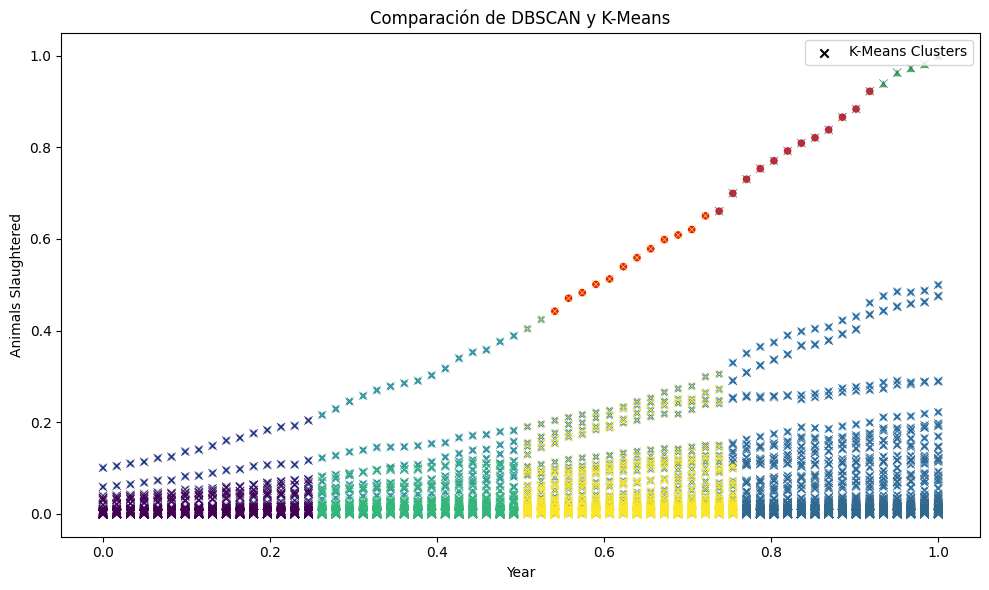

In [21]:
# DBSCAN
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan_labels = dbscan.fit_predict(df[['Year', 'Animals_Slaughtered']])

# KMeans
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=0)
kmeans_labels = kmeans.fit_predict(df[['Year', 'Animals_Slaughtered']])

plt.figure(figsize=(10, 6))

# Gráfico DBSCAN
sns.scatterplot(x=df['Year'], y=df['Animals_Slaughtered'], hue=dbscan_labels, palette='Set1', style=dbscan_labels, markers=['o', 'X', '^'], legend=None)

# Gráfico K-Means
sns.scatterplot(x=df['Year'], y=df['Animals_Slaughtered'], hue=kmeans_labels, palette='viridis', marker='x', legend=None)

plt.title('Comparación de DBSCAN y K-Means')
plt.xlabel('Year')
plt.ylabel('Animals Slaughtered')

# Leyenda DBSCAN
handles, labels_legend = plt.gca().get_legend_handles_labels()
labels_legend = ['Outliers' if label == '-1' else f'Cluster {label}' for label in labels_legend]
plt.legend(handles, labels_legend, title="DBSCAN Clusters/Outliers")

#leyenda KMeans
plt.scatter([], [], c='black', label='K-Means Clusters', marker='x')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


La comparación entre K-Means y DBSCAN muestra que DBSCAN es mejor para detectar outliers y adaptar los clusters a la densidad de los datos, generando grupos de diferentes formas y tamaños según la distribución de los puntos. Por otro lado, K-Means crea clusters de tamaño similar, agrupando todos los puntos sin considerar outliers, lo cual es útil para datos homogéneos y sin ruido. Esta diferencia resalta que DBSCAN es más adecuado para patrones complejos y dispersos, mientras que K-Means funciona mejor para datos bien distribuidos y agrupados.

# Implementación en un Pipeline

Integra todos estos pasos (EDA, preprocesamiento, K-Means, DBSCAN, visualización y evaluación) en un pipeline de Scikit-Learn. Esto ayuda a estandarizar el flujo de trabajo y hacer que el análisis sea más repetible y fácil de ajustar en el futuro.

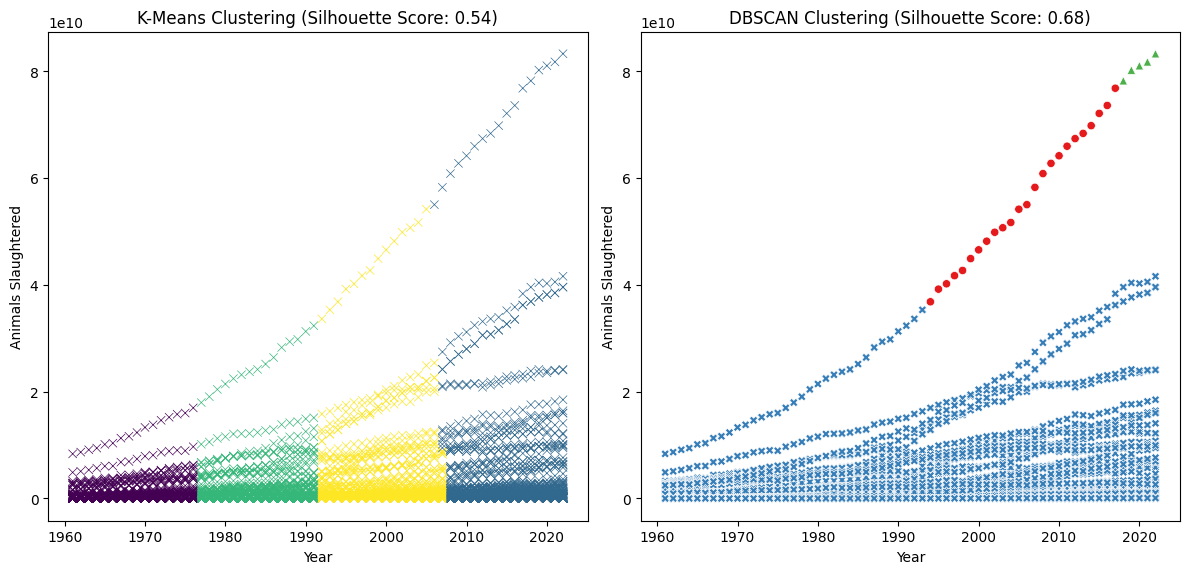

Silhouette Score for K-Means: 0.54
Silhouette Score for DBSCAN: 0.68


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

#cargar el dataset
ruta = "/content/drive/MyDrive/IA/number-of-land-animals-slaughtered-for-meat-per-year.csv"
df = pd.read_csv(ruta)

#renombrar las columnas para claridad
df.rename(columns={'Meat, total | 00001765 || Producing or slaughtered animals | 005320 || animals': 'Animals_Slaughtered'}, inplace=True)
df = df.drop(columns=['Code'])

#preprocesamiento: escalado de los datos
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[['Year', 'Animals_Slaughtered']])

#funcion para crear el pipeline y evaluarlo
def run_pipeline(df_scaled, df):
    pipeline = Pipeline([
        ('scaler', MinMaxScaler()),
    ])

    #crear nuevo df escalado
    df_scaled = pipeline.fit_transform(df[['Year', 'Animals_Slaughtered']])

    #KMeans con K = 4 (según la regla del codo)
    kmeans = KMeans(n_clusters=4, init='k-means++', random_state=0)
    kmeans_labels = kmeans.fit_predict(df_scaled)

    #DBSCAN con parametros eps=0.05 y min_samples=5
    dbscan = DBSCAN(eps=0.05, min_samples=5)
    dbscan_labels = dbscan.fit_predict(df_scaled)

    #evaluar el Silhouette Score para KMeans y DBSCAN
    silhouette_kmeans = silhouette_score(df_scaled, kmeans_labels)

    #excluir puntos de ruido en DBSCAN para calcular el Silhouette Score
    if len(set(dbscan_labels)) > 1 and -1 in dbscan_labels:
        dbscan_labels_non_noise = dbscan_labels[dbscan_labels != -1]
        df_scaled_non_noise = df_scaled[dbscan_labels != -1]
        silhouette_dbscan = silhouette_score(df_scaled_non_noise, dbscan_labels_non_noise)
    else:
        silhouette_dbscan = -1

    #visualización de los resultados
    plt.figure(figsize=(12, 6))

    #grafico de KMeans
    plt.subplot(1, 2, 1)
    sns.scatterplot(x=df['Year'], y=df['Animals_Slaughtered'], hue=kmeans_labels, palette='viridis', marker='x', legend=None)
    plt.title(f'K-Means Clustering (Silhouette Score: {silhouette_kmeans:.2f})')
    plt.xlabel('Year')
    plt.ylabel('Animals Slaughtered')

    #grafico de DBSCAN
    plt.subplot(1, 2, 2)

    #ajustar el número de marcadores según el numero de clusters en DBSCAN
    unique_labels = np.unique(dbscan_labels)
    markers = ['o', 'X', '^', 's'][:len(unique_labels)]

    sns.scatterplot(x=df['Year'], y=df['Animals_Slaughtered'], hue=dbscan_labels, palette='Set1', style=dbscan_labels, markers=markers, legend=None)
    plt.title(f'DBSCAN Clustering (Silhouette Score: {silhouette_dbscan:.2f})')
    plt.xlabel('Year')
    plt.ylabel('Animals Slaughtered')

    plt.tight_layout()
    plt.show()

    return silhouette_kmeans, silhouette_dbscan

silhouette_kmeans, silhouette_dbscan = run_pipeline(df_scaled, df)

print(f'Silhouette Score for K-Means: {silhouette_kmeans:.2f}')
print(f'Silhouette Score for DBSCAN: {silhouette_dbscan:.2f}')
